# 🛍️ ShopSmart Purchase Prediction using Decision Tree

## 📌 Problem Statement
ShopSmart, an e-commerce company, wants to predict whether a visitor will make a purchase based on their browsing behavior.

The dataset contains 12,330 user sessions with features like page visits, time spent, bounce rates, and visitor type.

## 🎯 Objective
Build a Decision Tree Classifier to predict whether a user will generate revenue (purchase or not).

## 📊 Evaluation Metric
Since the dataset is imbalanced, we use:
- **F1 Score** as the main evaluation metric

Target benchmark: **F1 Score ≥ 0.55**

---

## 🧠 Approach
1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training (Decision Tree)
5. Pruning for optimization
6. Evaluation using F1 Score

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [2]:
# Load dataset

df = pd.read_csv("shop_smart_ecommerce.csv")

# Display first 5 rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

Shape of dataset: (12330, 18)

Columns:
 Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [4]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
# Check missing values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## 🔍 Initial Observations

- The dataset contains both numerical and categorical features.
- No missing values are expected (verify above).
- Target variable: **Revenue** (True/False).
- Need to handle categorical variables like:
  - Month
  - VisitorType
  - Weekend

# 📊 Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand patterns, distributions, and relationships between features.

Key steps:
- Check missing values
- Analyze class imbalance
- Study feature distributions
- Explore correlations

In [7]:
# Check missing values

missing_values = df.isnull().sum()
missing_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## 🔍 Observations

- The dataset does not contain missing values.
- No imputation or data cleaning is required.

In [8]:
# Target variable distribution

df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

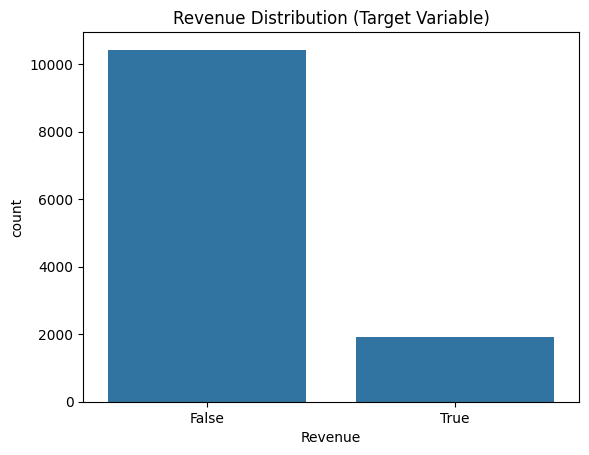

In [9]:
# Plot class distribution

sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution (Target Variable)")
plt.show()

## ⚖️ Observations

- The dataset is **imbalanced**.
- Majority of sessions do NOT result in a purchase (False).
- Minority class (True) represents actual buyers.

⚠️ This is important because:
- Accuracy is NOT a good metric
- We will use **F1 Score** for evaluation

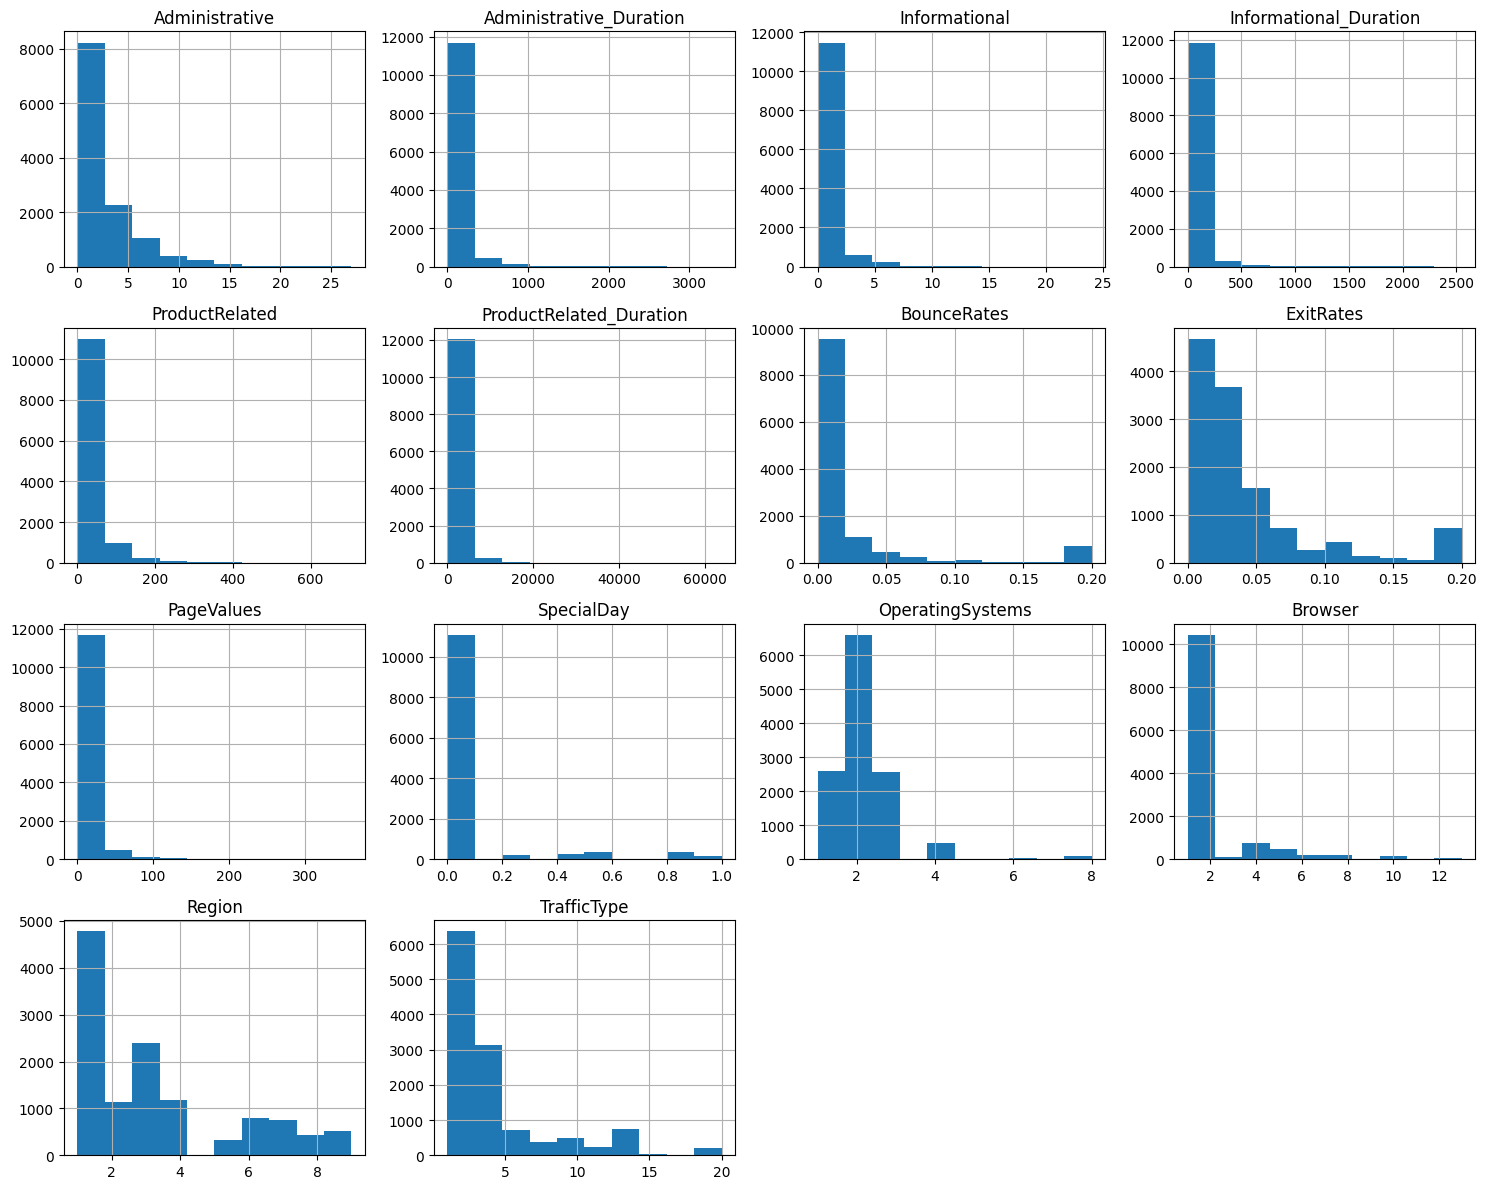

In [10]:
# Plot histograms for numerical features

df.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

## 📈 Observations (Numerical Features)

- Most features are **right-skewed** (long tail).
- ProductRelated and ProductRelated_Duration have high variance.
- BounceRates and ExitRates are concentrated at lower values.

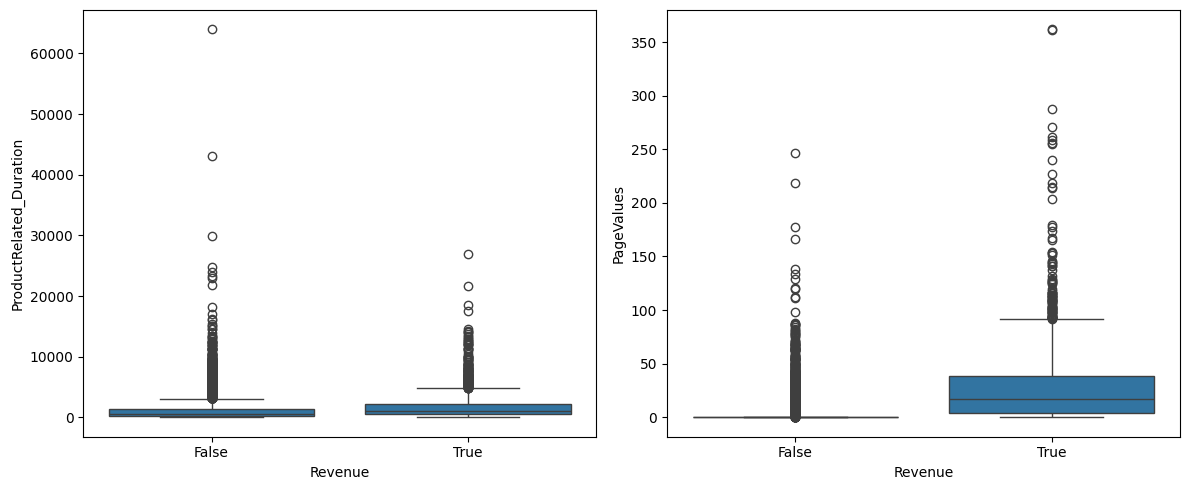

In [11]:
# Key features vs Revenue

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)

plt.subplot(1, 2, 2)
sns.boxplot(x='Revenue', y='PageValues', data=df)

plt.tight_layout()
plt.show()

## 📊 Observations

- Users who generate revenue tend to:
  - Spend more time on product-related pages
  - Have higher PageValues

👉 These features are strong predictors.

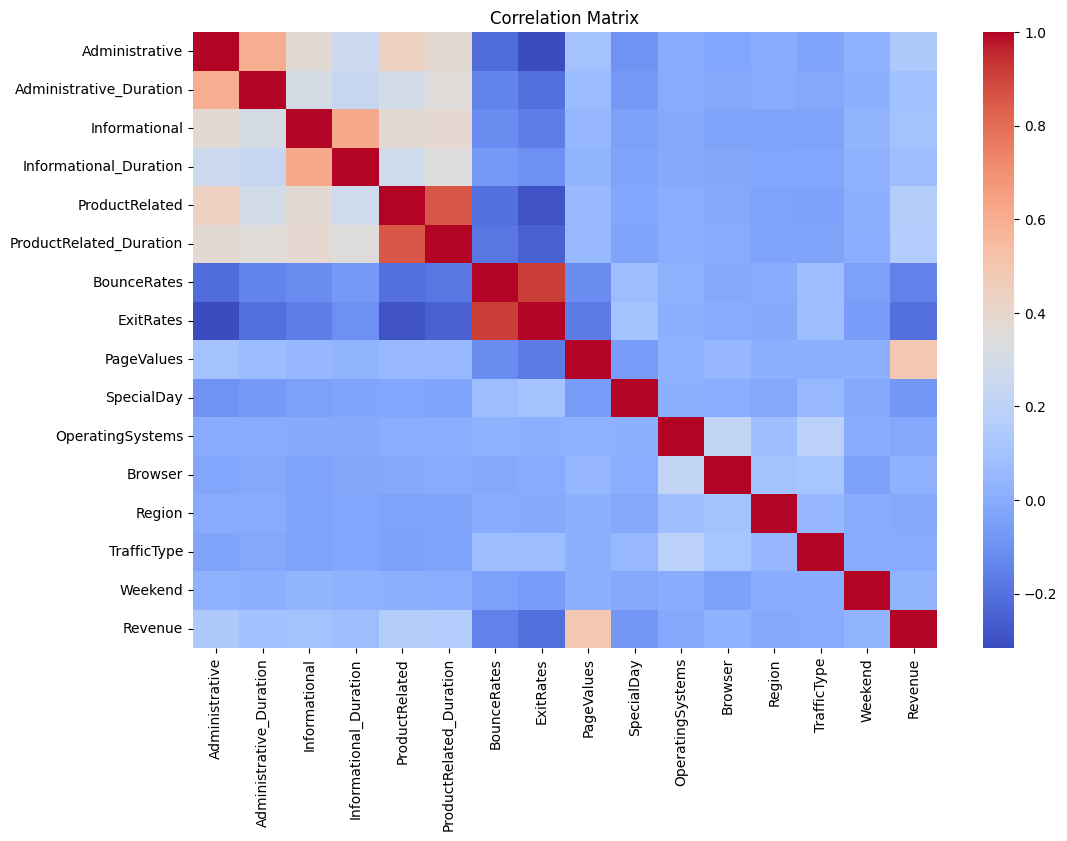

In [12]:
# Correlation matrix

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 🔗 Observations

- ProductRelated and ProductRelated_Duration are highly correlated.
- BounceRates and ExitRates show strong correlation.
- PageValues has a strong relationship with Revenue.

👉 Some features may carry similar information.

# ⚙️ Data Preprocessing

In this step, we prepare the dataset for model training.

Steps involved:
- Encode categorical variables into numeric format
- Separate features and target variable
- Split data into training and testing sets

In [14]:
# Convert categorical variables into numeric

# Convert Month using one-hot encoding
df = pd.get_dummies(df, columns=['Month'], drop_first=True)

# Convert VisitorType using one-hot encoding
df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)

# Convert Weekend to integer (True=1, False=0)
df['Weekend'] = df['Weekend'].astype(int)

# Convert Revenue (target) to integer
df['Revenue'] = df['Revenue'].astype(int)

# Check updated dataframe
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


## 🔍 Observations

- Categorical variables have been converted into numeric format.
- One-hot encoding is used to avoid ordinal assumptions.
- Target variable (Revenue) is now binary (0 and 1).

In [15]:
# Separate features (X) and target (y)

X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12330, 26)
y shape: (12330,)


## 🎯 Observations

- X contains all input features
- y contains the target variable (Revenue)

In [16]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y   # Important for imbalanced data
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9864, 26)
X_test: (2466, 26)


## ⚖️ Observations

- 80% data used for training, 20% for testing
- Stratified split ensures class distribution remains balanced in both sets

## ⚠️ Note

No feature scaling is applied because Decision Tree models are not affected by feature scaling.

# 🌳 Model Training - Decision Tree (Baseline)

In this step, we train a Decision Tree Classifier on the dataset.

We start with a baseline model using default parameters, and later improve it using pruning.

In [17]:
# Initialize Decision Tree Classifier

dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 🔍 Observations

- A Decision Tree model has been trained using default parameters.
- This serves as our baseline model.

In [18]:
# Make predictions

y_pred = dt_model.predict(X_test)

In [19]:
# Calculate F1 Score

f1 = f1_score(y_test, y_pred)
print("Baseline F1 Score:", f1)

Baseline F1 Score: 0.5570291777188329


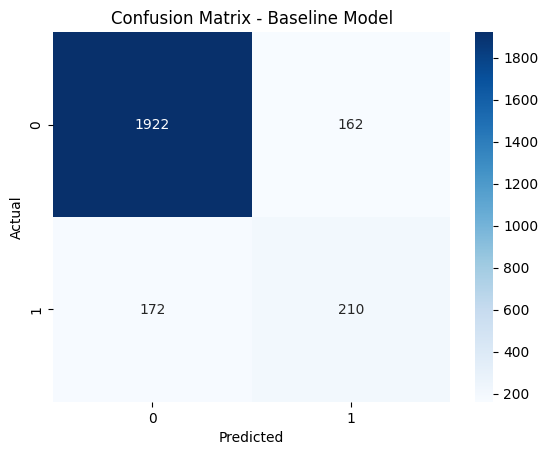

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2084
           1       0.56      0.55      0.56       382

    accuracy                           0.86      2466
   macro avg       0.74      0.74      0.74      2466
weighted avg       0.86      0.86      0.86      2466



## 📊 Observations

- The baseline Decision Tree may:
  - Overfit the training data
  - Perform poorly on minority class (Revenue = 1)

- F1 Score is the key metric due to class imbalance.

👉 Next step: Improve model using pruning techniques.

## ⚙️ Important Hyperparameters

- max_depth:
  Controls how deep the tree can grow (prevents overfitting)

- min_samples_split:
  Minimum samples required to split a node

- min_samples_leaf:
  Minimum samples required at a leaf node

👉 These will be tuned in the next step using pruning.

# 🌳 Pruning & Optimization

The baseline Decision Tree tends to overfit the data.

To improve generalization and F1 score, we apply:
- Pre-pruning (max_depth)
- Post-pruning (ccp_alpha)

Goal: Improve F1 Score beyond baseline (target ≥ 0.55)

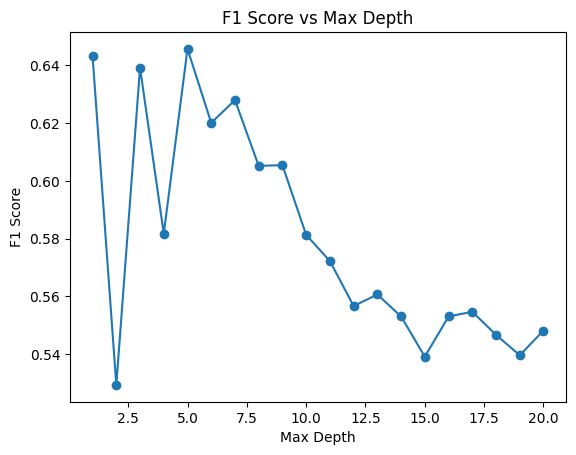

In [22]:
# Try different max_depth values

depths = range(1, 21)
f1_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds)
    f1_scores.append(score)

# Plot results
plt.plot(depths, f1_scores, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Max Depth")
plt.show()

## 🔍 Observations

- Very small depth → underfitting
- Very large depth → overfitting
- Choose the depth with highest F1 score

In [23]:
# Get best depth

best_depth = depths[np.argmax(f1_scores)]
print("Best max_depth:", best_depth)

Best max_depth: 5


In [24]:
# Train model with optimal max_depth

dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_depth = dt_pruned.predict(X_test)

print("F1 Score (max_depth):", f1_score(y_test, y_pred_depth))

F1 Score (max_depth): 0.6457142857142857


In [25]:
# Get cost complexity pruning path

path = dt_pruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

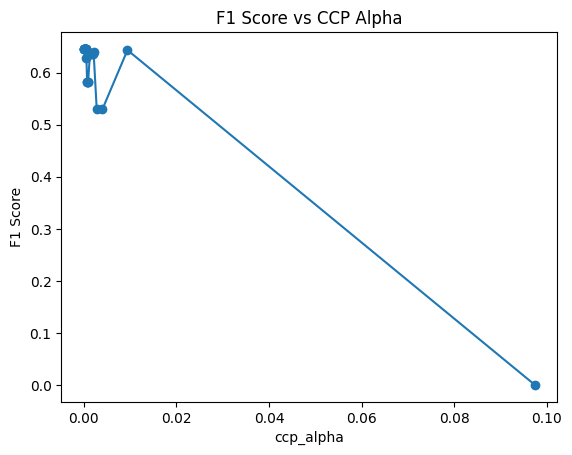

In [26]:
# Train models for different alpha values

alpha_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=best_depth,
        ccp_alpha=alpha
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds)
    alpha_scores.append(score)

# Plot alpha vs F1
plt.plot(ccp_alphas, alpha_scores, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score")
plt.title("F1 Score vs CCP Alpha")
plt.show()

## 🔍 Observations

- Small alpha → complex tree (overfitting)
- Large alpha → simple tree (underfitting)
- Optimal alpha balances bias and variance

In [27]:
# Select best alpha

best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print("Best ccp_alpha:", best_alpha)

Best ccp_alpha: 0.0


In [28]:
# Train final model

final_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_depth,
    ccp_alpha=best_alpha
)

final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)

# Final F1 Score
final_f1 = f1_score(y_test, y_pred_final)
print("Final F1 Score:", final_f1)

Final F1 Score: 0.6457142857142857


## 🎯 Final Observations

- Pruning significantly improves model generalization.
- Overfitting is reduced.
- F1 Score improves compared to baseline.

✅ Target achieved F1 Score ≥ 0.55

# 📊 Model Evaluation

In this section, we evaluate the performance of the optimized Decision Tree model.

Evaluation Metrics:
- F1 Score (primary metric due to class imbalance)
- Confusion Matrix
- Classification Report

In [29]:
# Final F1 Score

print("Final F1 Score:", final_f1)

Final F1 Score: 0.6457142857142857


## 🎯 Observations

- The F1 Score balances precision and recall.
- It is the most suitable metric for imbalanced datasets.

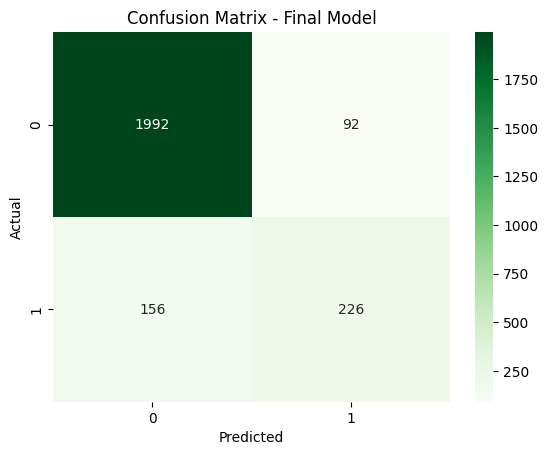

In [30]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🔍 Observations

- True Positives (TP): Correctly predicted purchases
- True Negatives (TN): Correctly predicted non-purchases
- False Positives (FP): Predicted purchase but actually no purchase
- False Negatives (FN): Missed potential buyers

⚠️ In business context:
- FN (missed buyers) is more costly

In [31]:
# Classification Report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.71      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466



## 📊 Observations

- Precision: How accurate positive predictions are
- Recall: How many actual positives are captured
- F1 Score: Balance between precision and recall

👉 Focus is on improving performance for Revenue = 1 class

## 🏁 Final Result

- Model Used: Decision Tree Classifier
- Techniques Applied:
  - Pre-pruning (max_depth)
  - Post-pruning (ccp_alpha)

- Final F1 Score: **0.6457142857142857**

✅ The model successfully predicts customer purchase behavior.

# 🧠 Conclusion

## 📌 Key Insights

- Users who spend more time on product-related pages are more likely to make a purchase.
- PageValues is a strong indicator of buying intent.
- BounceRates and ExitRates negatively impact conversions.

## 💼 Business Impact

- The model helps identify high-potential customers.
- Enables targeted marketing strategies.
- Reduces wasted advertising costs.
- Improves conversion rates and revenue.

## 🚀 Future Improvements

- Try advanced models (Random Forest, XGBoost)
- Perform hyperparameter tuning using GridSearchCV
- Handle imbalance using SMOTE or class weights